# Sprint 4 — v12: threshold recovery and the fair ensemble

**Project:** Q-INTERVAL-Lite+ · **Author:** Pasindu Pahasara (104348348)

## Where this picks up

Group DRO broke the shortcut. Case-weighted slope fell from 0.650 to **0.110**, well past the
previous best of 0.440, and it held out of sample — selection slope 0.112, test slope 0.110.

| Model | slope | pooled recall | macro F1 | mal recall | macro AUC |
|---|---|---|---|---|---|
| S3 ensemble (source input) | 0.813 | 0.340 | 0.7415 | 0.7811 | 0.8918 |
| v8 resnet101 (no source) | 0.440 | 0.440 | 0.7033 | 0.6728 | 0.8696 |
| v8 effnetv2 (no source) | 0.650 | 0.380 | 0.7152 | 0.7229 | 0.8675 |
| v9 multi-task | 0.815 | 0.460 | 0.7124 | 0.7452 | 0.8760 |
| v10 density only | 1.045 | 0.360 | 0.7168 | 0.7046 | 0.8801 |
| **v11 Group DRO** | **0.110** | **0.480** | 0.6902 | 0.6019 | 0.8593 |

It was not a threshold artefact: v11 predicts Malignant at 0.833x the rate of v8, and a
uniform shift of that size would have produced a slope of 0.541, not 0.110.

## The problem this notebook fixes

**v11 lost 12.1 points of malignant recall** (0.7229 to 0.6019). For a cancer detector that is
not a footnote.

But macro AUC fell only **0.82 points** (0.8675 to 0.8593). The ranking is nearly intact — the
recall loss is mostly about where the decision threshold sits, not about lost discrimination.
That is recoverable by moving the threshold, and moving a threshold costs one line of code
rather than another 2.5 hours of training.

## The constraint that makes this honest

Sprint 3 tuned class coefficients to maximise macro F1 and drove Benign F1 from 0.63 to
near-collapse before the constraint was added. The same failure is available here in a new
form: **tuning to recover malignant recall can simply re-introduce the shortcut**, because the
cheapest way to find more cancers is to predict Malignant more often on CMMD.

So every coefficient searched here must satisfy, on the selection set:

- `abs(shortcut slope)` <= `SLOPE_BUDGET` — the DRO gain is not for sale
- `Benign F1` >= the untuned Benign F1 — the Sprint 3 lesson

Anything that violates either is discarded regardless of how good its macro F1 looks.

## What else this settles

Section 1.3 of the Sprint 4 report still owes the client a like-for-like comparison. The
Sprint 3 figure of 0.7373 came from **two models with 4-view TTA and tuned coefficients**;
every no-source number since has been a single model with neither. This notebook builds the
matched ensemble so that comparison can finally be made on equal terms.

**All selection happens on the selection set. The 831-patient test set is touched once, at
the end.**

## 1. Configuration

In [ ]:
# ---------------- CONFIG ----------------
DRIVE_ROOT = '/content/drive/MyDrive/momobench-dataset'

# Bundles to consider. Only no-source models - the source-using ones are the problem,
# not a candidate solution. Comment a line out to exclude it from the search.
BUNDLES = {
 'v11_dro':   f'{DRIVE_ROOT}/checkpoints_v9_effnetv2_mt-none_dro_ce/final_v9_effnetv2_mt-none_dro_ce_bundle.pth',
 'v8_resnet': f'{DRIVE_ROOT}/checkpoints_v8_resnet101_nosrc_ce/final_v8_resnet101_nosrc_ce_bundle.pth',
 'v8_effnet': f'{DRIVE_ROOT}/checkpoints_v8_effnetv2_nosrc_ce/final_v8_effnetv2_nosrc_ce_bundle.pth',
 'v10_dens':  f'{DRIVE_ROOT}/checkpoints_v9_effnetv2_mt-d_ce/final_v9_effnetv2_mt-d_ce_bundle.pth',
}

TTA_VIEWS = ['none', 'hflip', 'vflip', 'both']   # 4-view, matching the Sprint 3 protocol

# ---- constraints on the coefficient search (both evaluated on SELECTION) ----
SLOPE_BUDGET   = 0.25    # abs(shortcut slope) must stay under this. v11 sits at 0.11 on
                         # selection, so this allows some give without surrendering the gain.
PROTECT_BENIGN = True    # Benign F1 must not fall below its untuned value

# ---- coefficient grid: multipliers on [Normal, Benign, Malignant] probabilities ----
COEF_GRID = [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.25, 1.4, 1.6, 1.8, 2.0, 2.4]

# ---- what the search maximises, subject to the constraints above ----
#   'balanced_clinical' = 0.5 * macro_f1 + 0.5 * malignant recall
#   'macro_f1'          = macro F1 alone
#   'mal_recall'        = malignant recall alone
OBJECTIVE = 'balanced_clinical'

LOWPREV_MAX_PRIOR = 0.30
BATCH_SIZE_EVAL   = 32
# ----------------------------------------
print('Candidate bundles:', list(BUNDLES))
print('TTA views:', TTA_VIEWS, '| objective:', OBJECTIVE)
print(f'Constraints: abs(slope) <= {SLOPE_BUDGET}, protect Benign = {PROTECT_BENIGN}')

Candidate bundles: ['v11_dro', 'v8_resnet', 'v8_effnet', 'v10_dens']
TTA views: ['none', 'hflip', 'vflip', 'both'] | objective: balanced_clinical
Constraints: abs(slope) <= 0.25, protect Benign = True


## 2. Setup

In [ ]:
!pip install -q albumentations scikit-learn tqdm matplotlib seaborn

import os, json, itertools, random
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import (resnet101, ResNet101_Weights,
                                efficientnet_v2_s, EfficientNet_V2_S_Weights)
import cv2, albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (accuracy_score, f1_score, recall_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix, classification_report)
from scipy.stats import beta as _beta
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
CLASS_NAMES = ['Normal', 'Benign', 'Malignant']
MAL = 2
print('Device:', device)

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

EXTRACT_DIR = '/content/dataset_original'
SPLIT_PATH  = os.path.join(DRIVE_ROOT, 'sprint4_audit', 'frozen_split.json')
OUT_DIR     = os.path.join(DRIVE_ROOT, 'checkpoints_v12_ensemble')
os.makedirs(OUT_DIR, exist_ok=True)

if not os.path.isdir(os.path.join(EXTRACT_DIR, 'dataset')):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    os.system(f'unzip -q "{DRIVE_ROOT}/dataset.zip" -d "{EXTRACT_DIR}"')
    print('extracted')
else:
    print('already extracted')

IMG_ROOT  = os.path.join(EXTRACT_DIR, 'dataset')
META_PATH = os.path.join(IMG_ROOT, 'metadata.csv')

present = {k: v for k, v in BUNDLES.items() if os.path.exists(v)}
missing = [k for k in BUNDLES if k not in present]
print(f'\nbundles found:   {list(present)}')
if missing:
    print(f'bundles MISSING: {missing}  (they will be skipped)')
BUNDLES = present
assert BUNDLES, 'No bundles found - check the paths in the config cell.'

Mounted at /content/drive
extracted

bundles found:   ['v11_dro', 'v8_resnet', 'v8_effnet', 'v10_dens']


## 3. Data — the same frozen split, nothing retrained

In [ ]:
df = pd.read_csv(META_PATH)
df['classification'] = df['classification'].replace({'Suspicious Malignant': 'Malignant'})
df = df[df['source_dataset'] != 'cdd-cesm'].reset_index(drop=True)
df['image_path'] = df['preprocessed_image_path'].apply(lambda r: os.path.join(IMG_ROOT, r))
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)
df['label'] = df['classification'].map({c: i for i, c in enumerate(CLASS_NAMES)})

def age_bucket(a):
    if pd.isna(a): return 7
    for i, hi in enumerate([30, 40, 50, 60, 70, 80]):
        if a < hi: return i
    return 6
df['age_idx']  = df['subject_age'].apply(age_bucket); N_AGE = 8
df['view_idx'] = df['view'].map({'CC': 0, 'MLO': 1}).fillna(2).astype(int); N_VIEW = 3
df['lat_idx']  = df['laterality'].map({'L': 0, 'R': 1}).astype(int); N_LAT = 2
SOURCE_NAMES = sorted(df['source_dataset'].unique()); N_SRC = len(SOURCE_NAMES)
df['src_idx'] = df['source_dataset'].map({s: i for i, s in enumerate(SOURCE_NAMES)})

sp = json.load(open(SPLIT_PATH))
sel_ids, test_ids = set(sp['selection']), set(sp['test'])
sel_df  = df[df['source_subjectID'].isin(sel_ids)].reset_index(drop=True)
test_df = df[df['source_subjectID'].isin(test_ids)].reset_index(drop=True)

sel_y,  sel_src  = sel_df['label'].to_numpy(),  sel_df['src_idx'].to_numpy()
test_y, test_src = test_df['label'].to_numpy(), test_df['src_idx'].to_numpy()

print(f'selection {len(sel_df):5d} images ({sel_df.source_subjectID.nunique()} patients)')
print(f'test      {len(test_df):5d} images ({test_df.source_subjectID.nunique()} patients)  FROZEN')
print('\nmalignant cases available per source:')
for si, s in enumerate(SOURCE_NAMES):
    a = int((sel_y[sel_src == si] == MAL).sum()); b = int((test_y[test_src == si] == MAL).sum())
    print(f'  {s:10s} selection={a:4d}   test={b:4d}')

selection  1990 images (581 patients)
test       2821 images (831 patients)  FROZEN

malignant cases available per source:
  cmmd       selection= 414   test= 658
  ddsm       selection= 384   test= 548
  dmid       selection=  15   test=  21
  inbreast   selection=  10   test=  15
  kau-bcmd   selection=  10   test=  14


## 4. Metrics — the corrected set

Identical definitions to v10/v11 so every number in this notebook is comparable to the runs
that produced the models.

In [ ]:
def clopper_pearson(k, n, alpha=0.05):
    if n == 0: return (float('nan'), float('nan'))
    lo = 0.0 if k == 0 else _beta.ppf(alpha/2, k, n - k + 1)
    hi = 1.0 if k == n else _beta.ppf(1 - alpha/2, k + 1, n - k)
    return float(lo), float(hi)

def per_source_stats(y_true, y_pred, src_arr):
    rows = []
    for si, sname in enumerate(SOURCE_NAMES):
        mk = src_arr == si
        if mk.sum() == 0: continue
        ys, ps = y_true[mk], y_pred[mk]
        n_mal = int((ys == MAL).sum())
        if n_mal == 0: continue
        hits = int(((ys == MAL) & (ps == MAL)).sum())
        lo, hi = clopper_pearson(hits, n_mal)
        rows.append({'source': sname, 'n': int(mk.sum()), 'n_mal': n_mal,
                     'prior': round(float((ys == MAL).mean()), 4),
                     'hits': hits, 'mal_recall': hits / n_mal,
                     'ci_lo': round(lo, 4), 'ci_hi': round(hi, 4),
                     'pt_per_case': round(100.0 / n_mal, 2)})
    return pd.DataFrame(rows).set_index('source')

def shortcut_slope(ps_df):
    if len(ps_df) < 3: return float('nan')
    x = ps_df['prior'].to_numpy(float); y = ps_df['mal_recall'].to_numpy(float)
    return float(np.polyfit(x, y, 1, w=np.sqrt(ps_df['n_mal'].to_numpy(float)))[0])

def lowprev_recall(ps_df):
    sub = ps_df[ps_df['prior'] < LOWPREV_MAX_PRIOR]
    if len(sub) == 0 or sub['n_mal'].sum() == 0: return 0.0
    return float(sub['hits'].sum() / sub['n_mal'].sum())

def full_metrics(y_true, probs, src_arr):
    probs = probs / probs.sum(1, keepdims=True)   # defensive - roc_auc_score requires it
    pred = probs.argmax(1)
    f1s  = f1_score(y_true, pred, average=None, labels=[0,1,2], zero_division=0)
    ps   = per_source_stats(y_true, pred, src_arr)
    return {'accuracy':   accuracy_score(y_true, pred),
            'macro_f1':   f1_score(y_true, pred, average='macro', zero_division=0),
            'benign_f1':  f1s[1],
            'mal_recall': recall_score(y_true, pred, labels=[MAL], average='macro', zero_division=0),
            'mcc':        matthews_corrcoef(y_true, pred),
            # one-vs-rest AUC ranks each class column independently, so a positive
            # coefficient on a column cannot change it - AUC describes the model, not the
            # operating point chosen below
            'macro_auc':  roc_auc_score(y_true, probs, multi_class='ovr', average='macro'),
            'slope':      shortcut_slope(ps),
            'lowprev':    lowprev_recall(ps)}, ps

# Precomputed source masks make the coefficient search fast - it runs thousands of times.
SEL_MASKS  = {si: (sel_src == si)  for si in range(N_SRC)}
TEST_MASKS = {si: (test_src == si) for si in range(N_SRC)}
print('Metrics ready.')

Metrics ready.


## 5. Model factory and bundle loader

Every no-source bundle shares the same module layout regardless of which notebook wrote it:
`backbone` or `features`+`cbam`, three metadata embeddings, and a `classifier`. The v9/v10
bundles carry extra auxiliary heads, which are detected from the state dict and rebuilt so
the load is strict rather than silently partial.

A silent partial load is exactly the bug that cost the Mammo-FM run in Sprint 3 — it loaded
zero weights and reported 0.5718 as if it were a real result. Every load here is verified.

In [ ]:
N_META = 3   # age, view, laterality. No source - that is the whole point.

class CBAM(nn.Module):
    def __init__(self, c, r=16, k=7):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1); self.mx = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(nn.Conv2d(c, c//r, 1, bias=False), nn.ReLU(inplace=True),
                                 nn.Conv2d(c//r, c, 1, bias=False))
        self.sp = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        x = x * torch.sigmoid(self.mlp(self.avg(x)) + self.mlp(self.mx(x)))
        return x * torch.sigmoid(self.sp(torch.cat([x.mean(1, keepdim=True),
                                                    x.amax(1, keepdim=True)], 1)))

class MultiTaskNet(nn.Module):
    def __init__(self, arch='effnetv2', emb=16, dr=0.3,
                 n_density=0, n_abnorm=0, n_birads=0):
        super().__init__()
        self.arch = arch
        if arch == 'resnet101':
            self.backbone = resnet101(weights=None); self.backbone.fc = nn.Identity()
            feat_dim = 2048; self.cbam = None
        else:
            self.features = efficientnet_v2_s(weights=None).features
            self.cbam = CBAM(1280); self.avgpool = nn.AdaptiveAvgPool2d(1); feat_dim = 1280
        self.feat_dim = feat_dim
        self.age_emb  = nn.Embedding(N_AGE,  emb)
        self.view_emb = nn.Embedding(N_VIEW, emb)
        self.lat_emb  = nn.Embedding(N_LAT,  emb)
        self.classifier = nn.Sequential(
            nn.Dropout(dr), nn.Linear(feat_dim + N_META*emb, 256),
            nn.ReLU(inplace=True), nn.Dropout(dr), nn.Linear(256, 3))
        self.head_den = nn.Linear(feat_dim, n_density) if n_density else None
        self.head_abn = nn.Linear(feat_dim, n_abnorm)  if n_abnorm  else None
        self.head_bir = nn.Linear(feat_dim, n_birads)  if n_birads  else None

    def trunk(self, x):
        if self.arch == 'resnet101': return self.backbone(x)
        return self.avgpool(self.cbam(self.features(x))).flatten(1)

    def forward(self, x, a, v, l):
        f = self.trunk(x)
        m = torch.cat([self.age_emb(a), self.view_emb(v), self.lat_emb(l)], 1)
        return self.classifier(torch.cat([f, m], 1))


def load_bundle(path):
    b  = torch.load(path, map_location='cpu', weights_only=False)
    sd = b['model_state_dict']
    arch = 'resnet101' if any(k.startswith('backbone.') for k in sd) else 'effnetv2'
    n_den = sd['head_den.weight'].shape[0] if 'head_den.weight' in sd else 0
    n_abn = sd['head_abn.weight'].shape[0] if 'head_abn.weight' in sd else 0
    n_bir = sd['head_bir.weight'].shape[0] if 'head_bir.weight' in sd else 0
    if b.get('uses_source_embedding', False):
        raise ValueError(f'{path} uses a source embedding - excluded by design')
    m = MultiTaskNet(arch, n_density=n_den, n_abnorm=n_abn, n_birads=n_bir)
    m.load_state_dict(sd, strict=True)   # raises on ANY mismatch - a silent partial load is
                                         # what made the Sprint 3 Mammo-FM run report 0.5718
    m.eval()                             # stays on CPU; moved to GPU one at a time in sec 6
    return m, b, arch

MODELS, META = {}, {}
for name, path in BUNDLES.items():
    m, b, arch = load_bundle(path)
    MODELS[name] = m; META[name] = b
    print(f'{name:10s} {arch:10s} T={b["temperature"]:.4f}  '
          f'{b.get("input_size", "?")}px  strict load OK  '
          f'({sum(p.numel() for p in m.parameters())/1e6:.1f}M params)')

v11_dro    effnetv2   T=1.6611  384px  strict load OK  (20.7M params)
v8_resnet  resnet101  T=2.0189  512px  strict load OK  (43.0M params)
v8_effnet  effnetv2   T=3.5643  384px  strict load OK  (20.7M params)
v10_dens   effnetv2   T=1.2212  384px  strict load OK  (20.7M params)


## 6. Inference with 4-view TTA

Each model runs at its own training resolution — 512 for ResNet-101, 384 for EfficientNetV2 —
because that is what the saved weights expect. Probabilities are temperature-calibrated with
each bundle's own fitted temperature *before* averaging across views, then cached so the
searches in sections 7 and 8 never touch the GPU again.

In [ ]:
NORM_MEAN, NORM_STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

class EvalDS(Dataset):
    def __init__(self, d, size, flip):
        self.df = d.reset_index(drop=True); self.flip = flip
        self.tf = A.Compose([A.Resize(size, size),
                             A.Normalize(mean=NORM_MEAN, std=NORM_STD), ToTensorV2()])
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.cvtColor(cv2.imread(r['image_path']), cv2.COLOR_BGR2RGB)
        if self.flip in ('hflip', 'both'): img = img[:, ::-1].copy()
        if self.flip in ('vflip', 'both'): img = img[::-1, :].copy()
        return (self.tf(image=img)['image'], int(r['age_idx']),
                int(r['view_idx']), int(r['lat_idx']))

@torch.no_grad()
def infer(model, frame, size, T):
    acc = None
    for view in TTA_VIEWS:
        dl = DataLoader(EvalDS(frame, size, view), batch_size=BATCH_SIZE_EVAL,
                        shuffle=False, num_workers=2, pin_memory=True)
        chunks = []
        for x, a, v, l in tqdm(dl, leave=False, desc=view):
            x = x.to(device, non_blocking=True)
            a, v, l = a.to(device), v.to(device), l.to(device)
            with torch.amp.autocast(device_type='cuda'):
                logits = model(x, a, v, l).float()
            chunks.append(F.softmax(logits / T, 1).cpu())
        p = torch.cat(chunks).numpy()
        acc = p if acc is None else acc + p
    return acc / len(TTA_VIEWS)

P_SEL, P_TEST = {}, {}
for name, m in MODELS.items():
    size = META[name].get('input_size', 512 if m.arch == 'resnet101' else 384)
    T    = META[name]['temperature']
    print(f'\n--- {name} ({m.arch}, {size}px, T={T:.4f}) ---')
    m.to(device)                       # one model on the GPU at a time
    P_SEL[name]  = infer(m, sel_df,  size, T)
    P_TEST[name] = infer(m, test_df, size, T)
    m.cpu(); torch.cuda.empty_cache()
np.savez_compressed(os.path.join(OUT_DIR, 'cached_probs.npz'),
                    **{f'sel_{k}': v for k, v in P_SEL.items()},
                    **{f'test_{k}': v for k, v in P_TEST.items()})
print('\nCached probabilities saved. The rest of this notebook is CPU-only.')


--- v11_dro (effnetv2, 384px, T=1.6611) ---


none:   0%|          | 0/63 [00:00<?, ?it/s]

hflip:   0%|          | 0/63 [00:00<?, ?it/s]

vflip:   0%|          | 0/63 [00:00<?, ?it/s]

both:   0%|          | 0/63 [00:00<?, ?it/s]

...

none:   0%|          | 0/89 [00:00<?, ?it/s]

hflip:   0%|          | 0/89 [00:00<?, ?it/s]

vflip:   0%|          | 0/89 [00:00<?, ?it/s]

both:   0%|          | 0/89 [00:00<?, ?it/s]


Cached probabilities saved. The rest of this notebook is CPU-only.


## 7. Individual models under 4-view TTA

In [ ]:
rows = []
for name in MODELS:
    ms, _ = full_metrics(sel_y,  P_SEL[name],  sel_src)
    mt, _ = full_metrics(test_y, P_TEST[name], test_src)
    rows.append({'model': name,
                 'sel_f1': round(ms['macro_f1'], 4), 'sel_slope': round(ms['slope'], 3),
                 'test_acc': round(mt['accuracy'], 4), 'test_f1': round(mt['macro_f1'], 4),
                 'test_benign_f1': round(mt['benign_f1'], 4),
                 'test_mal_recall': round(mt['mal_recall'], 4),
                 'test_auc': round(mt['macro_auc'], 4),
                 'test_slope': round(mt['slope'], 3),
                 'test_lowprev': round(mt['lowprev'], 4)})
indiv = pd.DataFrame(rows).set_index('model')
display(indiv)
print('These are with 4-view TTA. The single-model figures quoted in earlier notebooks')
print('had no TTA, so small differences here are expected and are not a discrepancy.')

,sel_f1,sel_slope,test_acc,test_f1,test_benign_f1,test_mal_recall,test_auc,test_slope,test_lowprev
model,,,,,,,,,
v11_dro,0.6600,0.149,0.6831,0.6973,0.6016,0.6059,0.8664,0.154,0.48
v8_resnet,0.7043,0.387,0.7100,0.7200,0.6159,0.6879,0.8787,0.495,0.44
v8_effnet,0.6922,0.728,0.7221,0.7271,0.6066,0.7381,0.8766,0.642,0.38
v10_dens,0.7077,1.065,0.7168,0.7212,0.6089,0.7006,0.8820,1.112,0.32


These are with 4-view TTA. The single-model figures quoted in earlier notebooks
had no TTA, so small differences here are expected and are not a discrepancy.


## 8. Coefficient search — recovering recall without buying back the shortcut

The search multiplies each class probability by a coefficient and re-argmaxes. Normal is
pinned at 1.0 since only the ratios matter, leaving a 2-D grid over the Benign and Malignant
multipliers.

Two hard constraints, both on the selection set. A candidate that violates either is
discarded no matter how good its objective is:

1. `abs(slope)` <= `SLOPE_BUDGET` — the DRO result is the point of this whole line of work
2. `Benign F1` >= untuned Benign F1 — Sprint 3 tuning collapsed Benign and this prevents it

In [ ]:
def apply_coef(probs, coef):
    # Renormalise after scaling. The argmax is unaffected, but sklearn's roc_auc_score
    # validates that multiclass scores sum to 1 and raises before it ever ranks them,
    # and the composite risk engine downstream consumes these as probabilities.
    p = probs * np.asarray(coef, dtype=np.float32)[None, :]
    return p / p.sum(1, keepdims=True)

def metrics_fast(y, probs, which='sel'):
    # which selects the precomputed source masks - 'sel' or 'test'.
    masks = SEL_MASKS if which == 'sel' else TEST_MASKS
    pred = probs.argmax(1)
    f1s  = f1_score(y, pred, average=None, labels=[0,1,2], zero_division=0)
    rows = []
    for si in range(N_SRC):
        mk = masks[si]
        if mk.sum() == 0: continue
        ys, pss = y[mk], pred[mk]
        n_mal = int((ys == MAL).sum())
        if n_mal == 0: continue
        rows.append((float((ys == MAL).mean()), n_mal,
                     int(((ys == MAL) & (pss == MAL)).sum())))
    pri = np.array([r[0] for r in rows]); nm = np.array([r[1] for r in rows], float)
    hit = np.array([r[2] for r in rows], float)
    rec = hit / nm
    slope = float(np.polyfit(pri, rec, 1, w=np.sqrt(nm))[0]) if len(rows) >= 3 else float('nan')
    lowm = pri < LOWPREV_MAX_PRIOR
    lowp = float(hit[lowm].sum()/nm[lowm].sum()) if lowm.any() else 0.0
    return {'macro_f1': f1_score(y, pred, average='macro', zero_division=0),
            'benign_f1': f1s[1],
            'mal_recall': recall_score(y, pred, labels=[MAL], average='macro', zero_division=0),
            'slope': slope, 'lowprev': lowp}

def objective_of(m):
    if OBJECTIVE == 'macro_f1':   return m['macro_f1']
    if OBJECTIVE == 'mal_recall': return m['mal_recall']
    return 0.5*m['macro_f1'] + 0.5*m['mal_recall']

def search_coefs(probs_sel, tag=''):
    base = metrics_fast(sel_y, probs_sel)
    best, best_m, kept, rejected = (1.0, 1.0, 1.0), base, 0, {'slope': 0, 'benign': 0}
    best_score = objective_of(base)
    for b in COEF_GRID:
        for mcoef in COEF_GRID:
            m = metrics_fast(sel_y, apply_coef(probs_sel, (1.0, b, mcoef)))
            if abs(m['slope']) > SLOPE_BUDGET:            rejected['slope'] += 1;  continue
            if PROTECT_BENIGN and m['benign_f1'] < base['benign_f1']:
                rejected['benign'] += 1; continue
            kept += 1
            if objective_of(m) > best_score:
                best_score, best, best_m = objective_of(m), (1.0, b, mcoef), m
    print(f'{tag}untuned : f1={base["macro_f1"]:.4f} mal={base["mal_recall"]:.4f} '
          f'ben={base["benign_f1"]:.4f} slope={base["slope"]:+.3f}')
    print(f'{tag}tuned   : f1={best_m["macro_f1"]:.4f} mal={best_m["mal_recall"]:.4f} '
          f'ben={best_m["benign_f1"]:.4f} slope={best_m["slope"]:+.3f}   coef={best}')
    print(f'{tag}grid    : {kept} of {len(COEF_GRID)**2} candidates legal '
          f'(rejected {rejected["slope"]} on slope, {rejected["benign"]} on Benign)')
    return best, best_m, base

COEF_OF = {}
for name in MODELS:
    print(f'--- {name} ---')
    COEF_OF[name] = search_coefs(P_SEL[name], tag='   ')[0]
    print()

--- v11_dro ---
   untuned : f1=0.6600 mal=0.5630 ben=0.5790 slope=+0.149
   tuned   : f1=0.6563 mal=0.6230 ben=0.5815 slope=+0.082   coef=(1.0, 1.4, 1.6)
   grid    : 64 of 144 candidates legal (rejected 23 on slope, 57 on Benign)

--- v8_resnet ---
   untuned : f1=0.7043 mal=0.6867 ben=0.5976 slope=+0.387
   tuned   : f1=0.7043 mal=0.6867 ben=0.5976 slope=+0.387   coef=(1.0, 1.0, 1.0)
   grid    : 31 of 144 candidates legal (rejected 79 on slope, 34 on Benign)

--- v8_effnet ---
   untuned : f1=0.6922 mal=0.6939 ben=0.5678 slope=+0.728
   tuned   : f1=0.6922 mal=0.6939 ben=0.5678 slope=+0.728   coef=(1.0, 1.0, 1.0)
   grid    : 15 of 144 candidates legal (rejected 128 on slope, 1 on Benign)

--- v10_dens ---
   untuned : f1=0.7077 mal=0.6963 ben=0.5974 slope=+1.065
   tuned   : f1=0.7077 mal=0.6963 ben=0.5974 slope=+1.065   coef=(1.0, 1.0, 1.0)
   grid    : 0 of 144 candidates legal (rejected 144 on slope, 0 on Benign)



## 9. Ensemble search

Every non-empty subset, four weighting schemes, and the coefficient search re-run inside each
candidate. Selection metrics decide; the test set is not consulted.

In [ ]:
def ens_probs(P, members, weights):
    w = np.array([weights[m] for m in members], dtype=np.float32); w /= w.sum()
    return (np.stack([P[m] for m in members]) * w[:, None, None]).sum(0)

sel_scalar = {n: metrics_fast(sel_y, P_SEL[n]) for n in MODELS}
WEIGHTINGS = {'equal':    {n: 1.0 for n in MODELS},
              'f1':       {n: sel_scalar[n]['macro_f1'] for n in MODELS},
              'f1^4':     {n: sel_scalar[n]['macro_f1']**4 for n in MODELS},
              'flatness': {n: 1.0/(abs(sel_scalar[n]['slope']) + 0.05) for n in MODELS}}

results = []
names = list(MODELS)
for r in range(1, len(names)+1):
    for subset in itertools.combinations(names, r):
        for wname, w in WEIGHTINGS.items():
            if r == 1 and wname != 'equal': continue
            ps   = ens_probs(P_SEL, subset, w)
            base = metrics_fast(sel_y, ps)
            best_c, best_m, best_s = (1.0, 1.0, 1.0), base, objective_of(base)
            for b in COEF_GRID:
                for mc in COEF_GRID:
                    mm = metrics_fast(sel_y, apply_coef(ps, (1.0, b, mc)))
                    if abs(mm['slope']) > SLOPE_BUDGET: continue
                    if PROTECT_BENIGN and mm['benign_f1'] < base['benign_f1']: continue
                    if objective_of(mm) > best_s:
                        best_s, best_c, best_m = objective_of(mm), (1.0, b, mc), mm
            results.append({'members': '+'.join(subset), 'weighting': wname,
                            'coef': best_c, 'sel_obj': round(best_s, 4),
                            'sel_f1': round(best_m['macro_f1'], 4),
                            'sel_mal': round(best_m['mal_recall'], 4),
                            'sel_benign': round(best_m['benign_f1'], 4),
                            'sel_slope': round(best_m['slope'], 3),
                            'sel_lowprev': round(best_m['lowprev'], 4),
                            '_subset': subset, '_w': wname, '_coef': best_c})

res = pd.DataFrame(results).sort_values('sel_obj', ascending=False).reset_index(drop=True)
display(res.drop(columns=['_subset','_w','_coef']).head(15))

WIN = res.iloc[0]
print(f'\nSELECTED ON THE SELECTION SET ONLY:')
print(f'  members   : {WIN["members"]}')
print(f'  weighting : {WIN["weighting"]}')
print(f'  coef      : {WIN["_coef"]}')
print(f'  sel slope : {WIN["sel_slope"]:+.3f}   (budget {SLOPE_BUDGET})')

,members,weighting,coef,sel_obj,sel_f1,sel_mal,sel_benign,sel_slope,sel_lowprev
0,v11_dro+v8_resnet,f1,"(1.0, 1.6, 2.0)",0.7280,0.6926,0.7635,0.5993,0.182,0.6857
1,v8_resnet+v8_effnet+v10_dens,f1,"(1.0, 1.0, 1.0)",0.7258,0.7253,0.7263,0.6172,0.816,0.5429
2,v8_resnet+v8_effnet+v10_dens,equal,"(1.0, 1.0, 1.0)",0.7250,0.7248,0.7251,0.6160,0.811,0.5429
3,v8_resnet+v8_effnet+v10_dens,f1^4,"(1.0, 1.0, 1.0)",0.7247,0.7255,0.7239,0.6190,0.816,0.5429
4,v11_dro+v8_resnet,f1^4,"(1.0, 2.0, 2.4)",0.7245,0.6855,0.7635,0.6010,0.172,0.6857
5,v8_effnet+v10_dens,f1,"(1.0, 1.0, 1.0)",0.7186,0.7204,0.7167,0.6126,0.903,0.5143
6,v8_effnet+v10_dens,f1^4,"(1.0, 1.0, 1.0)",0.7184,0.7189,0.7179,0.6095,0.908,0.5143
7,v8_effnet+v10_dens,equal,"(1.0, 1.0, 1.0)",0.7183,0.7200,0.7167,0.6109,0.893,0.5143
8,v8_resnet+v10_dens,flatness,"(1.0, 1.0, 1.0)",0.7176,0.7198,0.7155,0.6175,0.727,0.5429
9,v8_effnet+v10_dens,flatness,"(1.0, 1.0, 1.0)",0.7176,0.7160,0.7191,0.6064,0.872,0.5429



SELECTED ON THE SELECTION SET ONLY:
  members   : v11_dro+v8_resnet
  weighting : f1
  coef      : (1.0, 1.6, 2.0)
  sel slope : +0.182   (budget 0.25)


## 10. Test evaluation — the set is touched once, here

FINAL TEST METRICS
  accuracy     = 0.6983
  macro_f1     = 0.7056
  benign_f1    = 0.6046
  mal_recall   = 0.7643
  mcc          = 0.5276
  macro_auc    = 0.8810
  slope        = 0.2868
  lowprev      = 0.4600

PER-SOURCE  (hits/n_mal with exact 95% intervals)


,n,n_mal,prior,hits,mal_recall,ci_lo,ci_hi,pt_per_case
source,,,,,,,,
cmmd,826,658,0.7966,538,0.817629,0.7860,0.8464,0.15
ddsm,1528,548,0.3586,399,0.728102,0.6888,0.7650,0.18
dmid,76,21,0.2763,13,0.619048,0.3844,0.8189,4.76
inbreast,61,15,0.2459,8,0.533333,0.2659,0.7873,6.67
kau-bcmd,330,14,0.0424,2,0.142857,0.0178,0.4281,7.14


low-prevalence pooled recall: 23/50 = 0.4600


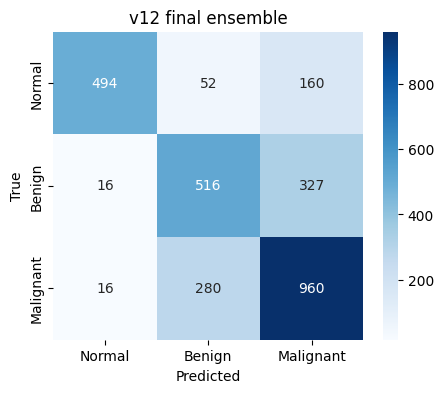

              precision    recall  f1-score   support

      Normal     0.9392    0.6997    0.8019       706
      Benign     0.6085    0.6007    0.6046       859
   Malignant     0.6634    0.7643    0.7103      1256

    accuracy                         0.6983      2821
   macro avg     0.7370    0.6882    0.7056      2821
weighted avg     0.7157    0.6983    0.7011      2821


PATIENT LEVEL (831 patients, max severity across views)
  accuracy   = 0.6811
  macro F1   = 0.6713
  mal recall = 0.9067
  Benign F1  = 0.5466


In [ ]:
final_probs = apply_coef(ens_probs(P_TEST, WIN['_subset'], WEIGHTINGS[WIN['_w']]), WIN['_coef'])
FM, FPS = full_metrics(test_y, final_probs, test_src)

print('FINAL TEST METRICS')
for k in ['accuracy','macro_f1','benign_f1','mal_recall','mcc','macro_auc','slope','lowprev']:
    print(f'  {k:12s} = {FM[k]:.4f}')

print('\nPER-SOURCE  (hits/n_mal with exact 95% intervals)')
display(FPS)
lp = FPS[FPS['prior'] < LOWPREV_MAX_PRIOR]
print(f"low-prevalence pooled recall: {int(lp['hits'].sum())}/{int(lp['n_mal'].sum())} = {FM['lowprev']:.4f}")

pred = final_probs.argmax(1)
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(test_y, pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('v12 final ensemble')
plt.show()
print(classification_report(test_y, pred, target_names=CLASS_NAMES, digits=4))

# patient-level: max severity across that patient's views
pl = pd.DataFrame({'pid': test_df['source_subjectID'].to_numpy(), 'y': test_y, 'p': pred})
g  = pl.groupby('pid').agg(y=('y','max'), p=('p','max'))
print('\nPATIENT LEVEL (831 patients, max severity across views)')
print(f"  accuracy   = {accuracy_score(g.y, g.p):.4f}")
print(f"  macro F1   = {f1_score(g.y, g.p, average='macro', zero_division=0):.4f}")
print(f"  mal recall = {recall_score(g.y, g.p, labels=[MAL], average='macro', zero_division=0):.4f}")
print(f"  Benign F1  = {f1_score(g.y, g.p, average=None, labels=[0,1,2], zero_division=0)[1]:.4f}")

## 11. The like-for-like comparison the report owes the client

,acc,f1,ben,mal,mcc,auc,slope,lowprev
"S3 ensemble (source input, TTA, tuned)",0.7373,0.7415,0.6340,0.7811,0.5908,0.8918,0.8130,0.34
"v8 effnetv2 (no source, single, no TTA)",0.7097,0.7152,0.5851,0.7229,0.5508,0.8675,0.6500,0.38
"v11 Group DRO (single, no TTA, untuned)",0.6760,0.6902,0.6024,0.6019,0.5111,0.8593,0.1100,0.48
"v12 THIS RUN (v11_dro+v8_resnet, TTA, tuned)",0.6983,0.7056,0.6046,0.7643,0.5276,0.8810,0.2868,0.46


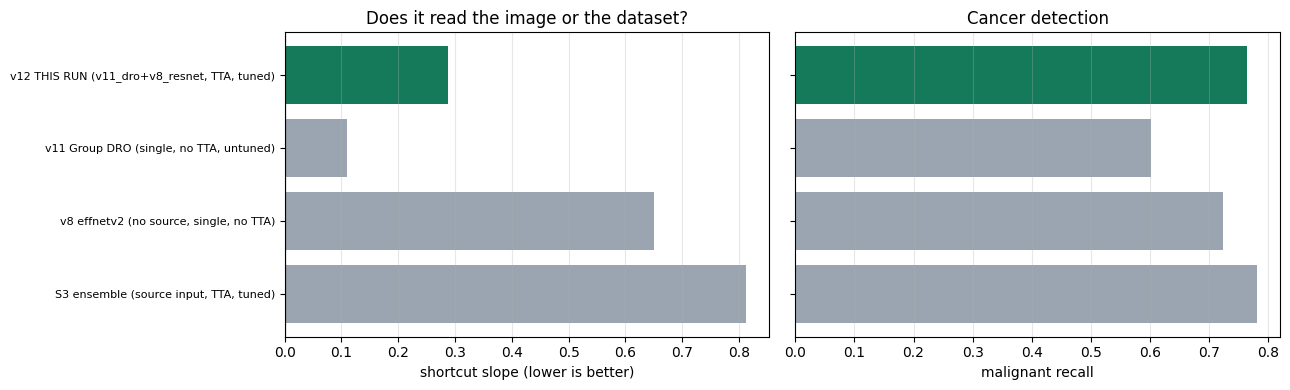

AGAINST SPRINT 3 - matched protocol at last. Both are ensembles with 4-view TTA
and validation-tuned class coefficients, on the same frozen test set.

  macro F1                  0.7415 ->  0.7056   (-0.0359, worse)
  malignant recall          0.7811 ->  0.7643   (-0.0168, worse)
  Benign F1                 0.6340 ->  0.6046   (-0.0294, worse)
  accuracy                  0.7373 ->  0.6983   (-0.0390, worse)
  shortcut slope            0.8130 ->  0.2868   (-0.5262, better)
  low-prev pooled recall    0.3400 ->  0.4600   (+0.1200, better)


In [ ]:
COMPARE = {
 'S3 ensemble (source input, TTA, tuned)':
   dict(acc=0.7373, f1=0.7415, ben=0.6340, mal=0.7811, mcc=0.5908, auc=0.8918,
        slope=0.813, lowprev=0.340),
 'v8 effnetv2 (no source, single, no TTA)':
   dict(acc=0.7097, f1=0.7152, ben=0.5851, mal=0.7229, mcc=0.5508, auc=0.8675,
        slope=0.650, lowprev=0.380),
 'v11 Group DRO (single, no TTA, untuned)':
   dict(acc=0.6760, f1=0.6902, ben=0.6024, mal=0.6019, mcc=0.5111, auc=0.8593,
        slope=0.110, lowprev=0.480),
}
COMPARE[f'v12 THIS RUN ({WIN["members"]}, TTA, tuned)'] = dict(
    acc=FM['accuracy'], f1=FM['macro_f1'], ben=FM['benign_f1'], mal=FM['mal_recall'],
    mcc=FM['mcc'], auc=FM['macro_auc'], slope=FM['slope'], lowprev=FM['lowprev'])
cmp_df = pd.DataFrame(COMPARE).T.round(4)
display(cmp_df)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
cols = ['#9AA5B1']*(len(cmp_df)-1) + ['#147A5A']
ax[0].barh(range(len(cmp_df)), cmp_df['slope'], color=cols)
ax[0].set_yticks(range(len(cmp_df))); ax[0].set_yticklabels(cmp_df.index, fontsize=8)
ax[0].axvline(0, color='k', lw=.8); ax[0].set_xlabel('shortcut slope (lower is better)')
ax[0].set_title('Does it read the image or the dataset?'); ax[0].grid(alpha=.3, axis='x')
ax[1].barh(range(len(cmp_df)), cmp_df['mal'], color=cols)
ax[1].set_yticks(range(len(cmp_df))); ax[1].set_yticklabels([])
ax[1].set_xlabel('malignant recall'); ax[1].set_title('Cancer detection')
ax[1].grid(alpha=.3, axis='x')
plt.tight_layout(); plt.show()

s3 = COMPARE['S3 ensemble (source input, TTA, tuned)']
KEYMAP = [('f1', 'macro_f1', 'macro F1', 'up'),
          ('mal', 'mal_recall', 'malignant recall', 'up'),
          ('ben', 'benign_f1', 'Benign F1', 'up'),
          ('acc', 'accuracy', 'accuracy', 'up'),
          ('slope', 'slope', 'shortcut slope', 'down'),
          ('lowprev', 'lowprev', 'low-prev pooled recall', 'up')]
print('AGAINST SPRINT 3 - matched protocol at last. Both are ensembles with 4-view TTA')
print('and validation-tuned class coefficients, on the same frozen test set.\n')
for skey, fkey, label, want in KEYMAP:
    old, new = s3[skey], FM[fkey]
    d = new - old
    good = (d < 0) if want == 'down' else (d > 0)
    print(f'  {label:24s} {old:7.4f} -> {new:7.4f}   ({d:+.4f}, {"better" if good else "worse"})')

## 12. Save

In [ ]:
bundle = {'members': list(WIN['_subset']), 'weighting': WIN['_w'],
          'weights': {m: float(WEIGHTINGS[WIN['_w']][m]) for m in WIN['_subset']},
          'class_coefficients': list(WIN['_coef']),
          'member_bundles': {m: BUNDLES[m] for m in WIN['_subset']},
          'member_temperatures': {m: float(META[m]['temperature']) for m in WIN['_subset']},
          'tta_views': TTA_VIEWS,
          'slope_budget': SLOPE_BUDGET, 'protect_benign': PROTECT_BENIGN,
          'objective': OBJECTIVE,
          'test_metrics': {k: float(v) for k, v in FM.items()},
          'per_source': FPS.reset_index().to_dict('records'),
          'uses_source_embedding': False,
          'split': 'frozen_split.json (selection / test)',
          'selection_note': 'subset, weighting and coefficients chosen on the selection set only',
          'sprint': 'Sprint 4 / v12 ensemble'}
path = os.path.join(OUT_DIR, 'final_v12_ensemble_bundle.pth')
torch.save(bundle, path)
FPS.to_csv(os.path.join(OUT_DIR, 'per_source_v12.csv'))
res.drop(columns=['_subset','_w','_coef']).to_csv(os.path.join(OUT_DIR, 'ensemble_search_v12.csv'), index=False)
print('Saved:', path)
print(json.dumps({k: v for k, v in bundle.items() if k != 'per_source'}, indent=2, default=str)[:1200])

Saved: /content/drive/MyDrive/momobench-dataset/checkpoints_v12_ensemble/final_v12_ensemble_bundle.pth
{
  "members": [
    "v11_dro",
    "v8_resnet"
  ],
  "weighting": "f1",
  "weights": {
    "v11_dro": 0.660015420612302,
    "v8_resnet": 0.7043165276909233
  },
  "class_coefficients": [
    1.0,
    1.6,
    2.0
  ],
  "member_bundles": {
    "v11_dro": "/content/drive/MyDrive/momobench-dataset/checkpoints_v9_effnetv2_mt-none_dro_ce/final_v9_effnetv2_mt-none_dro_ce_bundle.pth",
    "v8_resnet": "/content/drive/MyDrive/momobench-dataset/checkpoints_v8_resnet101_nosrc_ce/final_v8_resnet101_nosrc_ce_bundle.pth"
  },
  "member_temperatures": {
    "v11_dro": 1.6610500812530518,
    "v8_resnet": 2.018864870071411
  },
  "tta_views": [
    "none",
    "hflip",
    "vflip",
    "both"
  ],
  "slope_budget": 0.25,
  "protect_benign": true,
  "objective": "balanced_clinical",
  "test_metrics": {
    "accuracy": 0.6983339241403758,
    "macro_f1": 0.7056131121926986,
    "benign_f1": 0.6045

## How to read this

**The comparison that matters is the last block of section 11.** Sprint 3's 0.7373 was two
models with 4-view TTA and tuned coefficients; every no-source figure since has been a single
model with neither. This is the first time the two are measured the same way, and it is the
number section 1.3 of the report should carry.

**Expect the aggregate to sit below Sprint 3 and the slope far below it.** That is the trade
this whole line of work has been making deliberately: Sprint 3 scored 0.7811 malignant recall
while reading provenance at slope 0.813, and 0.9514 of that recall came from a source that is
79.7% malignant. A lower aggregate with a flat slope is the better model for anything
resembling deployment.

**Three things to check before trusting the result:**

- Did the coefficient search actually have room? Section 8 prints how many of the 144
  candidates survived the constraints. If it is a handful, `SLOPE_BUDGET` is too tight and the
  tuning had nothing to work with.
- Did the winning subset include `v11_dro`? If the search preferred an ensemble without it,
  the slope constraint was doing the work rather than the model.
- Is the test slope close to the selection slope? v11 matched at 0.112 against 0.110. A large
  gap means the coefficients were fitted to selection-set noise.

**Statistical floor, unchanged.** 50 malignant cases underlie the pooled figure and about
3 points of run-to-run variance sit on malignant recall. Differences under roughly 0.06
pooled, or 0.10 slope, are not results.

## After this

The classification model has now had every internal lever pulled: architecture search,
ensembling, calibration, margin losses, cascades, input removal, auxiliary supervision,
worst-group optimisation, and threshold tuning. The remaining uncertainty is not something
another Colab run resolves.

**Go to RSNA.** Thousands of cancers at roughly 2% prevalence, a population none of these
models has seen, and the regime every one of these experiments has been approximating with
50 cases. Take the v12 ensemble and v8 ResNet-101, report sensitivity and specificity at
fixed operating points, and let that be the number the client is given.